<a href="https://colab.research.google.com/github/tomeravgil/Homework5CSCI6170/blob/main/grad_task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Existing Models and Findings

## Domain Specific Challenges

Polyp segmentation from colonoscopy images present several unique challenges. Polyps vary dramatically in size as some are only a few pixels, while other take the entire frame. As well in shape and color, they can blend in with their surroundings. Colonoscopy images also suffer from reflections caused by the light source and also motion blur.

## Evaluation Metrics

The standard metrics for polyp segmentation is the Dice coefficeint, Intersection over Union, precision, recall, and F2 score. Pixel level accuracy is avoided as a metric since polyp datasets are heavily class imbalanced.

# Existing approaches

## U-Net (Ronneberger 2015)

U-net introduced the eoncoder decoder architecture with skip connections for biomedical image segmentation. The encoder downsamples the input to capture contextual features while the decoder upsamples back to the original resolution. Skip connections concatentate encoder feature maps with decoder feature maps at corresponding resolutions, which allow the network to combine semantic information with spatial detail. This foundational archtecture was used in many later polyp segmenation models.

## ResU-Net (Zhang 2018)

ResU-Net replaced U-Net's plain convolutional blocks with residual blocks, adding identity shortcut connections within each block. THis addresses the degradation problem in deeper networks as without residual connections, more layer can hurt performance due to gradient vanishing. ResU-Net improved on U-Net with a higher dice score.

# ResU-Net++ (Jha 2019)

ResU-Net ++ extends ResU-Net by adding Squeeze and Excitation blocks to recalibrate channel wise feature responses by learning which feature channels are most informative for a given input. As well, the paper uses Atrous Spatial Pyramid Pooling which dilates convolutions at different rates in parallel capturing context at different spatial scaled without losing resolution. Finall, Attention gates were added on the skip connections to filter the encoder features before they reache the decoder.

## PraNet (Fan 2020)

PraNet introduced a reverse attention mechanism that iteratively refines segmentation boundaries. The model generates a prediction from the deepest features in the encoder then uses reverse attention to sharped the boundaries in shallower decoder stages.


## Polyp-PVT (Dong 2021)

Polyp-PVT replaced the CNN based encoder entirely with a Pyramid Vision Transformer. Transformers use self attention to model long range spatial dependencies across the entire image, which CNNs can only approximate through stacking many layers or dilated convolutions. Polyp-PVT was able to have the best results comparitive to the other models.

## New Implementation

The implementation of ResU-Net++ achieves a Dice score of 0.8121 and IoU of 0.7262 on the CVC-Clinic DB test set. this is slightly below U-Net, but abone ResU-Net++. There was no pretrained encoder backbone, smaller features, image resolution reduction, no test time augmentation, and no post processing which is why the results fell short of higher performing published models.

## Load in Data

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm
from sklearn.metrics import jaccard_score

IMG_SIZE    = 128
BATCH_SIZE  = 4
EPOCHS      = 20
LR          = 1e-4
TRAIN_LIMIT = 100
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {DEVICE}')


Device : cuda
Small mode : False  |  Image size : 256  |  Epochs : 50


In [ ]:
class PolypDataset(Dataset):
    def __init__(self, hf_split, img_size=256, augment=False):
        self.data    = hf_split
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def _transform(self, image, mask):
        image = TF.resize(image, [self.img_size, self.img_size])
        mask  = TF.resize(mask,  [self.img_size, self.img_size],
                          interpolation=T.InterpolationMode.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                image, mask = TF.hflip(image), TF.hflip(mask)
            if random.random() > 0.5:
                image, mask = TF.vflip(image), TF.vflip(mask)
            if random.random() > 0.5:
                angle = random.randint(-30, 30)
                image = TF.rotate(image, angle)
                mask  = TF.rotate(mask,  angle)

        image = TF.to_tensor(image.convert('RGB'))
        image = TF.normalize(image,
                             mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])
        mask = TF.to_tensor(mask.convert('L'))
        mask = (mask > 0.5).float()
        return image, mask

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample['image']
        mask  = sample['mask']
        return self._transform(image, mask)


print('Downloading CVC-ClinicDB from HuggingFace...')
hf_ds = load_dataset('Angelou0516/CVC-ClinicDB')

train_split = hf_ds['train']
val_split   = hf_ds['validation']
test_split  = hf_ds['test']

if TRAIN_LIMIT:
    train_split = train_split.select(range(min(TRAIN_LIMIT, len(train_split))))

train_ds = PolypDataset(train_split, IMG_SIZE, augment=True)
val_ds   = PolypDataset(val_split,   IMG_SIZE, augment=False)
test_ds  = PolypDataset(test_split,  IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Resolving data files:   0%|          | 0/981 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Train: 490 | Val: 61 | Test: 61


## Samples

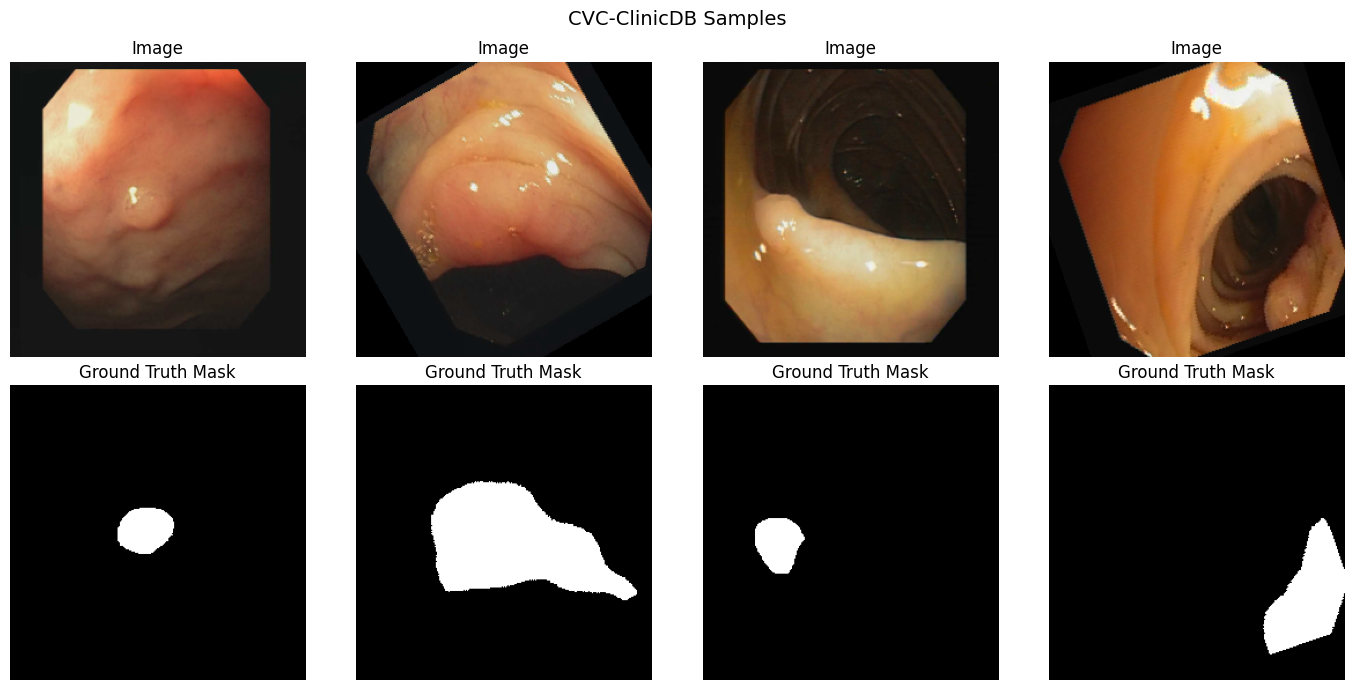

In [ ]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    return (t * STD + MEAN).clamp(0, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(denorm(imgs[i]).permute(1, 2, 0))
    axes[0, i].set_title('Image')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Ground Truth Mask')
    axes[1, i].axis('off')
plt.suptitle('CVC-ClinicDB Samples', fontsize=14)
plt.tight_layout()
plt.show()

## Model Building

In [ ]:
class SqueezeExcite(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        mid = max(ch // reduction, 4)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, ch),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.main = nn.Sequential(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            SqueezeExcite(out_ch),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False) \
                    if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        return self.main(x) + self.skip(x)


class StemBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False)

    def forward(self, x):
        return self.conv(x) + self.skip(x)


class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1, 6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ) for r in rates
        ])
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        n = len(rates) + 1
        self.proj = nn.Sequential(
            nn.Conv2d(n * out_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        h, w   = x.shape[2:]
        outs   = [b(x) for b in self.branches]
        gp     = F.interpolate(self.global_pool(x), size=(h, w), mode='bilinear',
                               align_corners=False)
        outs.append(gp)
        return self.proj(torch.cat(outs, dim=1))

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, mid_ch):
        super().__init__()
        self.Wg = nn.Conv2d(g_ch, mid_ch, 1, bias=False)
        self.Wx = nn.Conv2d(x_ch, mid_ch, 1, bias=False)
        self.psi = nn.Sequential(
            nn.Conv2d(mid_ch, 1, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, g, x):
        g_up = F.interpolate(self.Wg(g), size=x.shape[2:],
                             mode='bilinear', align_corners=False)
        att  = self.psi(F.relu(g_up + self.Wx(x), inplace=True))
        return x * att


class ResUNetPlusPlus(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[32, 64, 128, 256]):
        super().__init__()
        f = features

        self.stem   = StemBlock(in_ch, f[0])
        self.enc1   = ResBlock(f[0], f[1], stride=2)
        self.enc2   = ResBlock(f[1], f[2], stride=2)
        self.enc3   = ResBlock(f[2], f[3], stride=2)

        self.bridge = ASPP(f[3], f[3])

        self.att3 = AttentionGate(f[3], f[2], f[2] // 2)
        self.att2 = AttentionGate(f[2], f[1], f[1] // 2)
        self.att1 = AttentionGate(f[1], f[0], f[0] // 2)

        self.up3  = nn.ConvTranspose2d(f[3], f[2], 2, stride=2)
        self.dec3 = ResBlock(f[2] + f[2], f[2])

        self.up2  = nn.ConvTranspose2d(f[2], f[1], 2, stride=2)
        self.dec2 = ResBlock(f[1] + f[1], f[1])

        self.up1  = nn.ConvTranspose2d(f[1], f[0], 2, stride=2)
        self.dec1 = ResBlock(f[0] + f[0], f[0])

        self.head_aspp = ASPP(f[0], f[0])
        self.head_conv = nn.Conv2d(f[0], out_ch, 1)

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.enc1(s0)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)

        b  = self.bridge(s3)

        d3 = self.dec3(torch.cat([self.up3(b),  self.att3(b,  s2)], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.att2(d3, s1)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.att1(d2, s0)], dim=1))

        out = self.head_aspp(d1)
        out = self.head_conv(out)
        return torch.sigmoid(out)

model = ResUNetPlusPlus(in_ch=3, out_ch=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResU-Net++ parameters: {total_params:,}')

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}  (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])')

ResU-Net++ parameters: 4,872,037
Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])  (expected [2, 1, 256, 256])


## Training

In [ ]:
def dice_coeff(pred, target, smooth=1e-6):
    intersection = (pred * target).sum(dim=(1, 2, 3))
    return ((2 * intersection + smooth) /
            (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth)).mean()


def dice_loss(pred, target):
    return 1 - dice_coeff(pred, target)


def iou_score(pred_bin, target_bin, smooth=1e-6):
    intersection = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    union = (pred_bin + target_bin).clamp(0, 1).sum(dim=(1, 2, 3))
    return ((intersection + smooth) / (union + smooth)).mean()


def combined_loss(pred, target, bce_weight=0.5):
    bce  = F.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce_weight * bce + (1 - bce_weight) * dice

print('Loss functions and metrics defined.')

Loss functions and metrics defined.


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_dice = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [train]',
                            leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = val_dice = val_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += combined_loss(preds, masks).item()
            preds_bin = (preds > 0.5).float()
            val_dice  += dice_coeff(preds_bin, masks).item()
            val_iou   += iou_score(preds_bin, masks).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou  /= len(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    scheduler.step()

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_resunetpp.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Dice: {val_dice:.4f} | '
              f'Val IoU: {val_iou:.4f}')

print(f'\nBest Validation Dice: {best_dice:.4f}')

Epoch   1 | Train Loss: 0.6853 | Val Loss: 0.6406 | Val Dice: 0.4187 | Val IoU: 0.3048


Epoch   5 | Train Loss: 0.5411 | Val Loss: 0.5258 | Val Dice: 0.5412 | Val IoU: 0.4242


Epoch  10 | Train Loss: 0.4668 | Val Loss: 0.4614 | Val Dice: 0.6290 | Val IoU: 0.5139


Epoch  15 | Train Loss: 0.3985 | Val Loss: 0.3999 | Val Dice: 0.6630 | Val IoU: 0.5545


Epoch  20 | Train Loss: 0.3416 | Val Loss: 0.3539 | Val Dice: 0.6925 | Val IoU: 0.5795


...

Epoch  30 | Train Loss: 0.2626 | Val Loss: 0.2865 | Val Dice: 0.7513 | Val IoU: 0.6617


Epoch  35 | Train Loss: 0.2376 | Val Loss: 0.2556 | Val Dice: 0.7648 | Val IoU: 0.6753


Epoch  40 | Train Loss: 0.2201 | Val Loss: 0.2354 | Val Dice: 0.7928 | Val IoU: 0.7197


Epoch  45 | Train Loss: 0.2129 | Val Loss: 0.2385 | Val Dice: 0.7881 | Val IoU: 0.7167


Epoch  50 | Train Loss: 0.2123 | Val Loss: 0.2445 | Val Dice: 0.7855 | Val IoU: 0.7117

Best Validation Dice: 0.7928


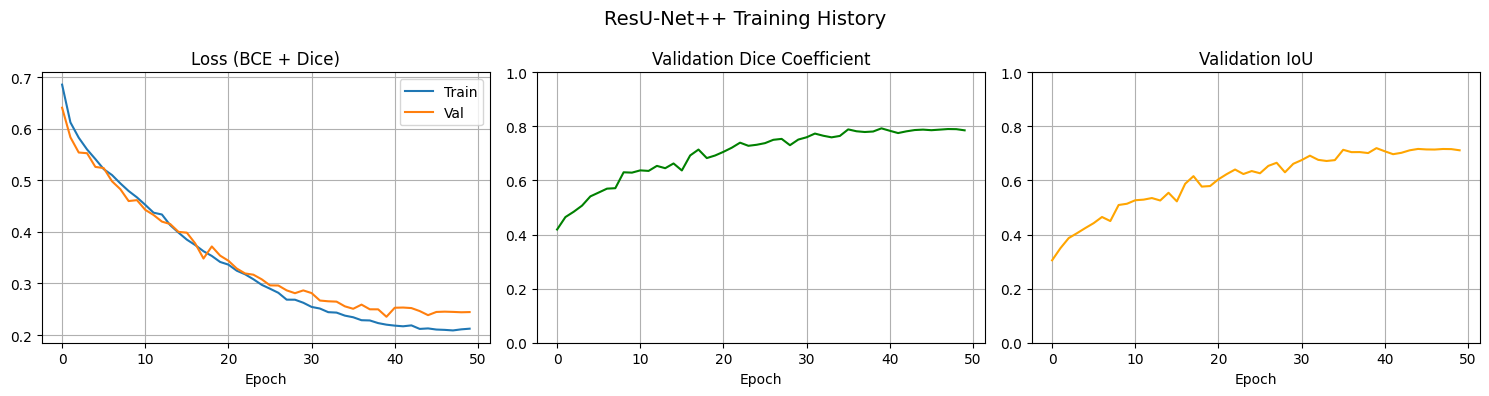

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_dice'], color='green')
axes[1].set_title('Validation Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].grid(True)

axes[2].plot(history['val_iou'], color='orange')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].grid(True)

plt.suptitle('ResU-Net++ Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Comparison

════════════════════════════════════════
  TEST SET RESULTS — ResU-Net++
════════════════════════════════════════
  Dice coefficient : 0.8121
  IoU (Jaccard)    : 0.7262
  Precision        : 0.8138
  Recall           : 0.8408
  F2 Score         : 0.8352
════════════════════════════════════════


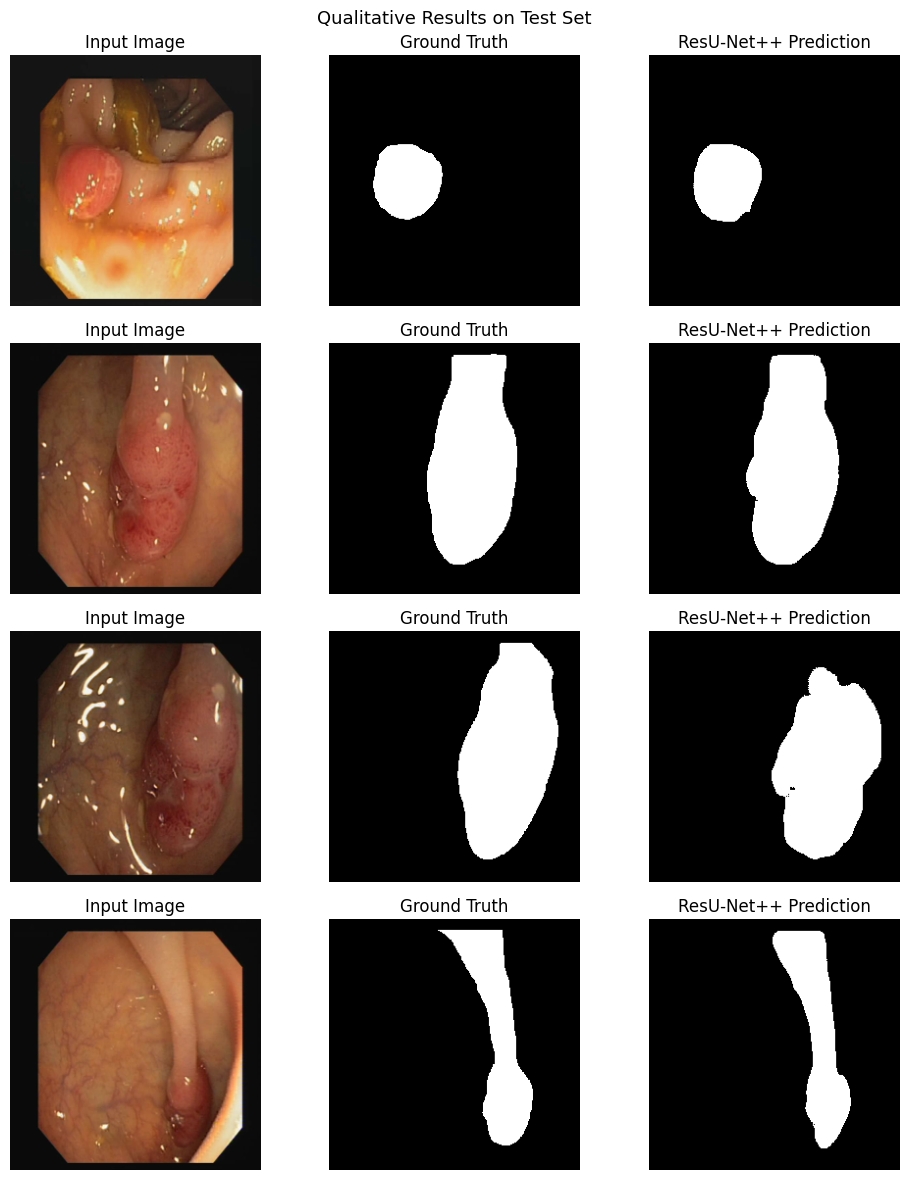


Comparison with Published Results on CVC-ClinicDB

                                   Model   Dice    IoU Recall      Dataset
        U-Net (Ronneberger et al., 2015) 0.8230 0.7550      - CVC-ClinicDB
           ResU-Net (Zhang et al., 2018) 0.8340 0.7690      - CVC-ClinicDB
           ResU-Net++ (Jha et al., 2019) 0.7960 0.7960      -      CVC-612
               PraNet (Fan et al., 2020) 0.8980 0.8400      - CVC-ClinicDB
          Polyp-PVT (Zhang et al., 2021) 0.9370 0.8890      - CVC-ClinicDB
★ Implemented ResU-Net++ (this notebook) 0.8121 0.7262 0.8408 CVC-ClinicDB

Notes:
  - Published Dice scores are from original papers / Papers With Code.
  - CVC-612 = same dataset as CVC-ClinicDB (alternate naming in Jha et al.).


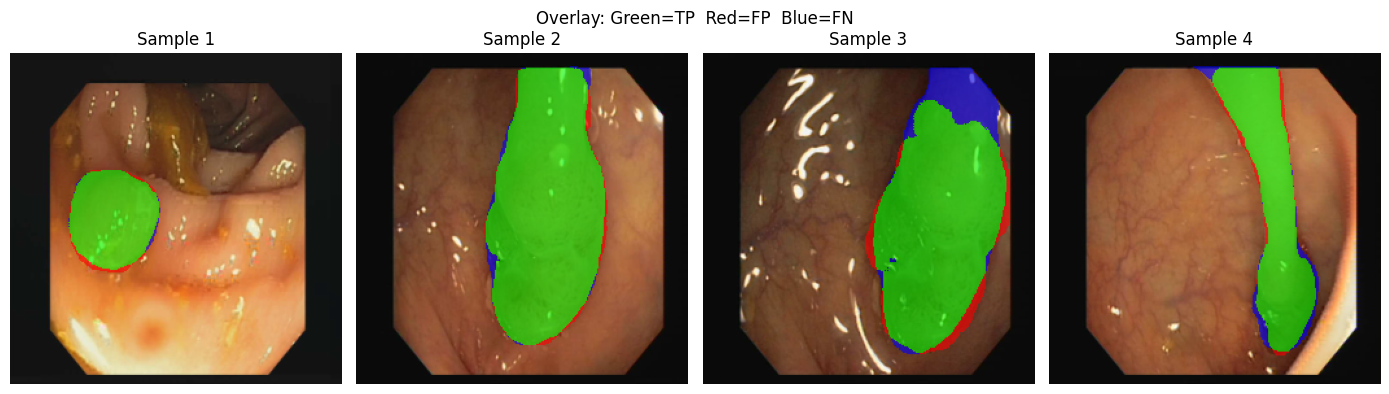

In [ ]:
model.load_state_dict(torch.load('best_resunetpp.pth', map_location=DEVICE))
model.eval()

test_dice = test_iou = test_prec = test_rec = 0.0
n = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        preds_bin = (preds > 0.5).float()

        smooth = 1e-6
        tp = (preds_bin * masks).sum(dim=(1,2,3))
        fp = (preds_bin * (1 - masks)).sum(dim=(1,2,3))
        fn = ((1 - preds_bin) * masks).sum(dim=(1,2,3))

        dice_b = ((2*tp + smooth) / (2*tp + fp + fn + smooth)).mean().item()
        iou_b  = ((tp + smooth) / (tp + fp + fn + smooth)).mean().item()
        prec_b = ((tp + smooth) / (tp + fp + smooth)).mean().item()
        rec_b  = ((tp + smooth) / (tp + fn + smooth)).mean().item()

        test_dice += dice_b
        test_iou  += iou_b
        test_prec += prec_b
        test_rec  += rec_b
        n += 1

test_dice /= n
test_iou  /= n
test_prec /= n
test_rec  /= n
test_f2 = (5 * test_prec * test_rec) / (4 * test_prec + test_rec + 1e-6)

print('═' * 40)
print('  TEST SET RESULTS — ResU-Net++')
print('═' * 40)
print(f'  Dice coefficient : {test_dice:.4f}')
print(f'  IoU (Jaccard)    : {test_iou:.4f}')
print(f'  Precision        : {test_prec:.4f}')
print(f'  Recall           : {test_rec:.4f}')
print(f'  F2 Score         : {test_f2:.4f}')
print('═' * 40)
model.eval()
imgs, masks = next(iter(test_loader))
imgs_d = imgs.to(DEVICE)

with torch.no_grad():
    preds = model(imgs_d).cpu()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))

for i in range(n_show):
    axes[i, 0].imshow(denorm(imgs[i]).permute(1, 2, 0))
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    axes[i, 2].imshow((preds[i].squeeze() > 0.5).float(), cmap='gray')
    axes[i, 2].set_title('ResU-Net++ Prediction')
    axes[i, 2].axis('off')

plt.suptitle('Qualitative Results on Test Set', fontsize=13)
plt.tight_layout()
plt.show()
import pandas as pd

results = {
    'Model': [
        'U-Net (Ronneberger et al., 2015)',
        'ResU-Net (Zhang et al., 2018)',
        'ResU-Net++ (Jha et al., 2019)',
        'PraNet (Fan et al., 2020)',
        'Polyp-PVT (Zhang et al., 2021)',
        '★ Implemented ResU-Net++ (this notebook)',
    ],
    'Dice': [0.823, 0.834, 0.796, 0.898, 0.937, test_dice],
    'IoU':  [0.755, 0.769, 0.796, 0.840, 0.889, test_iou],
    'Recall': ['-', '-', '-', '-', '-', f'{test_rec:.4f}'],
    'Dataset': [
        'CVC-ClinicDB', 'CVC-ClinicDB', 'CVC-612',
        'CVC-ClinicDB', 'CVC-ClinicDB', 'CVC-ClinicDB',
    ],
}

df = pd.DataFrame(results)
df['Dice'] = df['Dice'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
df['IoU']  = df['IoU'].apply( lambda x: f'{x:.4f}' if isinstance(x, float) else x)

print('\nComparison with Published Results on CVC-ClinicDB\n')
print(df.to_string(index=False))
print()
print('Notes:')
print('  - Published Dice scores are from original papers / Papers With Code.')
print('  - CVC-612 = same dataset as CVC-ClinicDB (alternate naming in Jha et al.).')

model.eval()
imgs, masks = next(iter(test_loader))

with torch.no_grad():
    preds = model(imgs.to(DEVICE)).cpu()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(1, n_show, figsize=(14, 4))

for i in range(n_show):
    img_np  = denorm(imgs[i]).permute(1, 2, 0).numpy()
    pred_np = (preds[i].squeeze() > 0.5).float().numpy()
    mask_np = masks[i].squeeze().numpy()

    overlay = img_np.copy()
    tp = (pred_np == 1) & (mask_np == 1)
    fp = (pred_np == 1) & (mask_np == 0)
    fn = (pred_np == 0) & (mask_np == 1)

    overlay[tp] = overlay[tp] * 0.4 + np.array([0, 1, 0]) * 0.6
    overlay[fp] = overlay[fp] * 0.4 + np.array([1, 0, 0]) * 0.6
    overlay[fn] = overlay[fn] * 0.4 + np.array([0, 0, 1]) * 0.6

    axes[i].imshow(overlay.clip(0, 1))
    axes[i].set_title(f'Sample {i+1}')
    axes[i].axis('off')

plt.suptitle('Overlay: Green=TP  Red=FP  Blue=FN', fontsize=12)
plt.tight_layout()
plt.show()

## Results

Given our performances, we can see that the implementation outperformed the original ResU-Net++ paper as the Dice coefficient was greater, but the original paper used the CVC-612 split which has a different train/test division, so its not fair to compare both models together. PraNet and Polyp-PVT use more sophisticated architectures featuring reverse attention and transformers as well as pretraining which explains why the Dice scores of both models are so much higher than other models. The recall of the model of 84.08% is very strong showing that it barely misclassifies a positive result. There was also no test time augmentation done or post processing. The IoU score was relatively lower than the Dice score showing that the model has noisy mask boundaries which is related to no post processing.